### Regressao linear 

#### 1. Correlaçoes

#### Correlação de Pearson

In [4]:
import pandas as pd
from random import *
import numpy as np

In [17]:
lista1 = []
for i in range (5000):
    a = float(gauss(0,10))
    lista1.append(a)

In [19]:
lista2 = []
for i in range (5000):
    a = float(gauss(15,2))
    lista2.append(a)

In [21]:
np.mean(lista1)

0.003245232196584459

In [23]:
np.mean(lista2)

15.07099499716402

### Realizando o teste de normalidade de Shapiro Wilk

In [28]:
from scipy.stats import shapiro
stat1, p1 = shapiro(lista1)
if p1 > 0.05:
    print("A hipotese nula nao pode ser rejeitada( os dados sao normalmentes distribuidos)")
else:
    print("A hipotese nula é refeitada (Os dados nao sao normalmente distribuitos)")

A hipotese nula nao pode ser rejeitada( os dados sao normalmentes distribuidos)


In [32]:
from scipy.stats import shapiro
stat1, p2 = shapiro(lista2)
if p2 > 0.05:
    print("A hipotese nula nao pode ser rejeitada( os dados sao normalmentes distribuidos)")
else:
    print("A hipotese nula é refeitada (Os dados nao sao normalmente distribuitos)")

A hipotese nula nao pode ser rejeitada( os dados sao normalmentes distribuidos)


In [34]:
p1, p2

(0.5597735761538223, 0.32635353979380427)

### Dadas as variaveis normalizadas para alfa = 5%, entao façamos a correlação de Pearson

In [43]:
from scipy.stats import pearsonr
r1, p3 = pearsonr(lista1,lista2)
if p3 > 0.5:
    print("A hipotese nula nao pode ser rejeitada(nao ha relação entre as duas variaveis)")
else:
    print("A hipotese nula é refeitada (Ha relação entre as duas variaveis)")

A hipotese nula nao pode ser rejeitada(nao ha relação entre as duas variaveis)


In [41]:
r1

0.0030998699689381917

### Correlação nao linear 

In [129]:
data = pd.read_csv("atlas2010.csv", decimal=".")

In [131]:
data

,ano,uf,mun,nome_mun,nome_micro,nome_meso,espvida,fectot,mort1,mort5,...,pia1517,pia18m,pop,popt,i_escolaridade,i_freq_prop,idhm,idhm_e,idhm_l,idhm_r
0,2010,Rondonia,1100015,alta floresta d'oeste,cacoal,leste rondoniense,70.75,2.24,23.80,25.49,...,1602,16431,24097,22429,0.00,1.0,1.00,1.00,1.0,1.00
1,2010,Rondonia,1100023,ariquemes,ariquemes,leste rondoniense,73.36,1.91,19.20,20.53,...,5256,60213,89766,88730,1.00,1.0,1.00,0.60,1.0,1.00
2,2010,Rondonia,1100031,cabixi,colorado do oeste,leste rondoniense,70.39,2.15,24.80,26.58,...,381,4306,6303,6156,0.00,0.7,0.65,1.00,1.0,0.65
3,2010,Rondonia,1100049,cacoal,cacoal,leste rondoniense,74.27,1.90,14.30,15.38,...,4547,54356,78141,76876,0.00,1.0,1.00,0.62,1.0,1.00
4,2010,Rondonia,1100056,cerejeiras,colorado do oeste,leste rondoniense,72.94,2.12,18.10,19.42,...,1033,11786,16942,16815,0.43,1.0,1.00,1.00,1.0,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5560,2010,Goias,5222005,vianópolis,pires do rio,sul goiano,74.10,2.10,14.40,17.04,...,711,8914,12501,12445,0.00,1.0,1.00,1.00,1.0,0.71
5561,2010,Goias,5222054,vicentinópolis,meia ponte,sul goiano,73.25,2.29,15.70,18.51,...,380,5190,7288,7239,0.00,1.0,1.00,1.00,1.0,1.00
5562,2010,Goias,5222203,vila boa,entorno de brasília,leste goiano,74.07,2.64,14.50,17.09,...,268,3065,4685,4531,0.00,1.0,1.00,1.00,1.0,1.00
5563,2010,Goias,5222302,vila propício,entorno de brasília,leste goiano,73.09,2.67,15.90,18.80,...,314,3476,4739,4523,0.33,1.0,1.00,1.00,1.0,1.00


In [133]:
from scipy.stats import spearmanr
r2, p4 = spearmanr(data.fectot, data.mort1)
if p4 > 0.05:
    print("A hipotese nula nao pode ser rejeitada(nao ha relação entre as duas variaveis)")
else:
    print("A hipotese nula é refeitada (Ha relação entre as duas variaveis)")
    

A hipotese nula é refeitada (Ha relação entre as duas variaveis)


In [140]:
r2

0.5533766373042982

### Covariancia 

In [152]:
covariance = np.cov(data.fectot, data.mort1)
cov_xy = covariance[0, 1]
var_x = covariance[0, 0]
var_y = covariance[1, 1]

### Regressao Linear Simples

Text(0, 0.5, 'fectot')

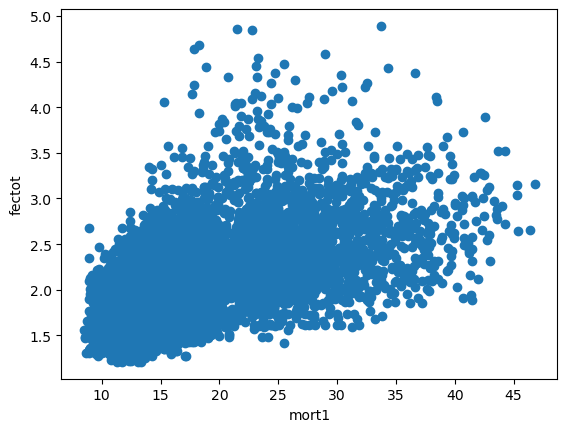

In [138]:
import matplotlib.pyplot as plt
plt.scatter(data.mort1, data.fectot)
plt.xlabel('mort1')
plt.ylabel('fectot')

In [156]:
import statsmodels.formula.api as sm
model = sm.ols(formula="fectot ~ mort1", data=data).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 fectot   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.264
Method:                 Least Squares   F-statistic:                     1995.
Date:                Mon, 28 Jul 2025   Prob (F-statistic):               0.00
Time:                        17:10:35   Log-Likelihood:                -3219.6
No. Observations:                5565   AIC:                             6443.
Df Residuals:                    5563   BIC:                             6457.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.4931      0.017     89.711      0.0

In [166]:
grupos = data['uf']
from statsmodels.formula.api import mixedlm
mixed_model = mixedlm(formula="fectot ~ mort1",groups=grupos, data=data)
result = mixed_model.fit()
print(result.summary())

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: fectot    
No. Observations: 5565    Method:             REML      
No. Groups:       27      Scale:              0.1168    
Min. group size:  1       Log-Likelihood:     -2002.1911
Max. group size:  853     Converged:          Yes       
Mean group size:  206.1                                 
---------------------------------------------------------
           Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
---------------------------------------------------------
Intercept  1.765     0.101  17.563  0.000   1.568   1.962
mort1      0.032     0.001  26.175  0.000   0.030   0.034
Group Var  0.251     0.209                               



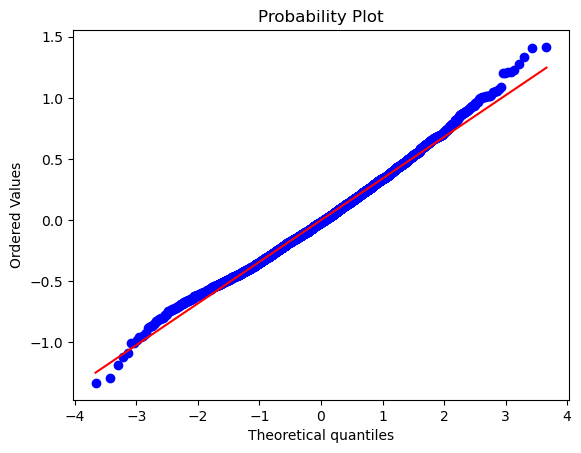

In [174]:
residual = result.resid
residuo = 0
for i in range(len(residual)):
    novo_residuo = residual[i] * residual[i]
    residuo_total_nm = residuo + novo_residuo
    
residuo_total_nm
from scipy import stats
stats.probplot(residual, dist="norm", plot=plt)
plt.show()

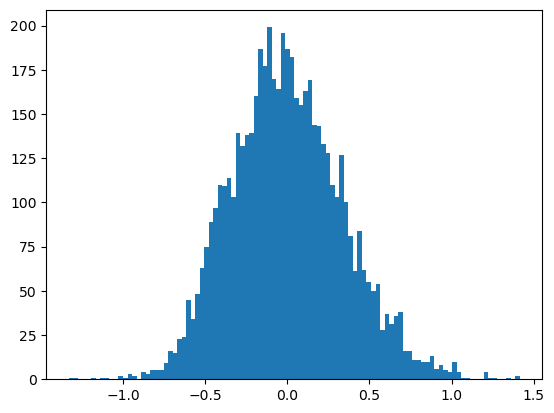

In [180]:
plt.hist(residual, bins=100)
plt.show()

### Regressao logistica Binaria

In [188]:
#importações
import pandas as pd
from sklearn.linear_model import LogisticRegression
from scipy.stats import pearsonr
from scipy.stats import chisquare
import matplotlib.pyplot as plt


In [192]:
df = pd.DataFrame({"Colesterol": [200,240,220,180,260],
                   "Doença_Cardiaca": [1,1,0,0,1]})

In [194]:
df

,Colesterol,Doença_Cardiaca
0,200,1
1,240,1
2,220,0
3,180,0
4,260,1


In [196]:
x = df[["Colesterol"]]
y = df["Doença_Cardiaca"] # variavel dependente

In [198]:
x

,Colesterol
0,200
1,240
2,220
3,180
4,260


In [200]:
y

0    1
1    1
2    0
3    0
4    1
Name: Doença_Cardiaca, dtype: int64

In [202]:
# Criando um modelo de regressao lopgistica
model = LogisticRegression()
model.fit(x,y)

print(model.intercept_)
print(model.coef_)

[-11.34454144]
[[0.05439225]]


In [204]:
x_pred = pd.DataFrame({"Colesterol": [220]})
y_pred = model.predict_proba(x_pred)[0][1]

y_pred

0.6506174957831965

In [206]:
model.predict_proba(x_pred)

array([[0.3493825, 0.6506175]])

### Presssupostos do modelo

In [209]:
# 1. Variavel dependente ser binaria

In [211]:
# 2. Linearidade entre dep e indep

In [219]:
pearsonr(df.Colesterol, df.Doença_Cardiaca) # ha indicios de linearidades dependentes

PearsonRResult(statistic=0.5773502691896257, pvalue=0.30806800925035743)

In [221]:
# 3 e 4 Erros uniformes e independentes

In [223]:
x_pred = df[["Colesterol"]]
y_pred = model.predict_proba(x_pred)[:,1]
y_pred

array([0.38554198, 0.84678435, 0.6506175 , 0.17451857, 0.94253759])

In [225]:
y = df["Doença_Cardiaca"]
y

0    1
1    1
2    0
3    0
4    1
Name: Doença_Cardiaca, dtype: int64

In [227]:
residuos = y - y_pred
residuos

0    0.614458
1    0.153216
2   -0.650617
3   -0.174519
4    0.057462
Name: Doença_Cardiaca, dtype: float64

In [229]:
stat, p = chisquare(residuos, f_exp = None)
if p > 0.05:
    print("Os dados nao seguem uma distribuição uniforme (p = {:.3f})".format(p))
else:
    print("Os dados seguem uma distribuição uniforme (p = {:.3f})".format(p))

Os dados seguem uma distribuição uniforme (p = 0.000)


In [231]:
# 5. Amostra deve ser representativa 

#### Metricas para avaliação do medelo

In [250]:
#acuracia
from sklearn.metrics import accuracy_score
acuracia = accuracy_score(y,y_pred>0.5)
print(acuracia)

0.6


In [252]:
#Sensibilidade
from sklearn.metrics import recall_score
sensibilidade = recall_score(y, (y_pred>0.5))
print(sensibilidade)

0.6666666666666666


In [254]:
#Especificidade
from sklearn.metrics import confusion_matrix
def specificity(y, y_pred_int):
    cm = confusion_matrix(y, y_pred_int)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)
    return specificity
especificidade = specificity(y, (y_pred>0.5))
print(especificidade)

0.5


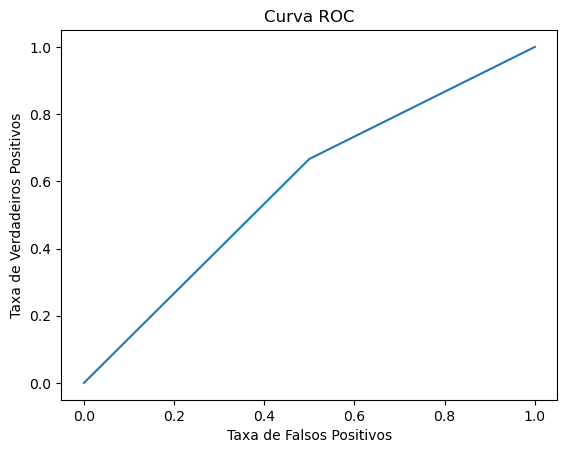

In [259]:
#Roc Curva
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y, (y_pred>0.5))
plt.plot(fpr, tpr)
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.show()

#### Teste com dados reais

In [262]:
#importando a base de dados
data = pd.read_csv('dados_alunos.csv')

In [264]:
data

,probabilidade,faixa_etaria,regiao,mat_basica,mat_superior,estatistica,tecnologia
0,1,Entre 26 e 44 anos,Sudeste,Um pouco,Um pouco,Um pouco,Nao
1,1,Entre 26 e 44 anos,Sul,Um pouco,Um pouco,Um pouco,Um pouco
2,1,Entre 26 e 44 anos,Sudeste,Um pouco,Um pouco,Um pouco,Um pouco
3,0,Acima de 44 anos,Sudeste,Nao,Um pouco,Nunca tive contato por tempo significativo,Nao
4,1,Entre 19 e 25 anos,Sudeste,Um pouco,Nunca tive contato por tempo significativo,Nunca tive contato por tempo significativo,Nao
...,...,...,...,...,...,...,...
168,1,Entre 26 e 44 anos,Sul,Um pouco,Um pouco,Um pouco,Nao
169,1,Entre 19 e 25 anos,Nordeste,Nao,Um pouco,Um pouco,Um pouco
170,0,Entre 26 e 44 anos,Centro oeste,Nao,Um pouco,Um pouco,Um pouco
171,1,Entre 26 e 44 anos,Sul,"Sim, muita","Sim, muita",Nunca tive contato por tempo significativo,Um pouco


In [270]:
data = pd.get_dummies(data, columns=['faixa_etaria', 'regiao', 'mat_basica', 'mat_superior', 'estatistica', 'tecnologia'])
data

,probabilidade,faixa_etaria_18 anos ou menos,faixa_etaria_Acima de 44 anos,faixa_etaria_Entre 19 e 25 anos,faixa_etaria_Entre 26 e 44 anos,regiao_Centro oeste,regiao_Fora do Brasil,regiao_Nordeste,regiao_Norte,regiao_Sudeste,...,mat_superior_Nunca tive contato por tempo significativo,"mat_superior_Sim, muita",mat_superior_Um pouco,estatistica_Nao,estatistica_Nunca tive contato por tempo significativo,"estatistica_Sim, muita",estatistica_Um pouco,tecnologia_Nao,"tecnologia_Sim, muita",tecnologia_Um pouco
0,1,False,False,False,True,False,False,False,False,True,...,False,False,True,False,False,False,True,True,False,False
1,1,False,False,False,True,False,False,False,False,False,...,False,False,True,False,False,False,True,False,False,True
2,1,False,False,False,True,False,False,False,False,True,...,False,False,True,False,False,False,True,False,False,True
3,0,False,True,False,False,False,False,False,False,True,...,False,False,True,False,True,False,False,True,False,False
4,1,False,False,True,False,False,False,False,False,True,...,True,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,1,False,False,False,True,False,False,False,False,False,...,False,False,True,False,False,False,True,True,False,False
169,1,False,False,True,False,False,False,True,False,False,...,False,False,True,False,False,False,True,False,False,True
170,0,False,False,False,True,True,False,False,False,False,...,False,False,True,False,False,False,True,False,False,True
171,1,False,False,False,True,False,False,False,False,False,...,False,True,False,False,True,False,False,False,False,True


In [274]:
data.columns

Index(['probabilidade', 'faixa_etaria_18 anos ou menos',
       'faixa_etaria_Acima de 44 anos', 'faixa_etaria_Entre 19 e 25 anos',
       'faixa_etaria_Entre 26 e 44 anos', 'regiao_Centro oeste',
       'regiao_Fora do Brasil', 'regiao_Nordeste', 'regiao_Norte',
       'regiao_Sudeste', 'regiao_Sul', 'mat_basica_Nao',
       'mat_basica_Sim, muita', 'mat_basica_Um pouco', 'mat_superior_Nao',
       'mat_superior_Nunca tive contato por tempo significativo',
       'mat_superior_Sim, muita', 'mat_superior_Um pouco', 'estatistica_Nao',
       'estatistica_Nunca tive contato por tempo significativo',
       'estatistica_Sim, muita', 'estatistica_Um pouco', 'tecnologia_Nao',
       'tecnologia_Sim, muita', 'tecnologia_Um pouco'],
      dtype='object')

In [276]:
X = data[['faixa_etaria_18 anos ou menos',
       'faixa_etaria_Acima de 44 anos', 'faixa_etaria_Entre 19 e 25 anos',
       'faixa_etaria_Entre 26 e 44 anos', 'regiao_Centro oeste',
       'regiao_Fora do Brasil', 'regiao_Nordeste', 'regiao_Norte',
       'regiao_Sudeste', 'regiao_Sul', 'mat_basica_Nao',
       'mat_basica_Sim, muita', 'mat_basica_Um pouco', 'mat_superior_Nao',
       'mat_superior_Nunca tive contato por tempo significativo',
       'mat_superior_Sim, muita', 'mat_superior_Um pouco', 'estatistica_Nao',
       'estatistica_Nunca tive contato por tempo significativo',
       'estatistica_Sim, muita', 'estatistica_Um pouco', 'tecnologia_Nao',
       'tecnologia_Sim, muita', 'tecnologia_Um pouco']]
y = data['probabilidade']

In [278]:
# Criamos o modelo de regressão logística
model = LogisticRegression()

# Treinamos o modelo com os dados de treinamento
model.fit(X, y)

LogisticRegression()

In [280]:
y_pred = model.predict_proba(X)[:, 1] #do lado esquerdo, a probabilidade de não acontecer, do lado direito o contrário

In [282]:
#valores de teste de y
y = data['probabilidade']

In [286]:
residuos = y - y_pred
residuos

0      0.030602
1      0.090181
2      0.039615
3     -0.855264
4      0.060826
         ...   
168    0.070508
169    0.243455
170   -0.524194
171    0.024683
172    0.155587
Name: probabilidade, Length: 173, dtype: float64

In [288]:
stat, p = chisquare(residuos, f_exp=None)
# Verifica o resultado do teste
if p < 0.05:
    print('Os dados não seguem uma distribuição uniforme (p = {:.3f})'.format(p))
else:
    print('Os dados seguem uma distribuição uniforme (p = {:.3f})'.format(p))

Os dados não seguem uma distribuição uniforme (p = 0.000)


(array([ 6.,  2.,  8., 21., 25., 86., 15.,  1.,  3.,  6.]),
 array([-0.9098188 , -0.72765394, -0.54548909, -0.36332423, -0.18115937,
         0.00100548,  0.18317034,  0.3653352 ,  0.54750005,  0.72966491,
         0.91182977]),
 <BarContainer object of 10 artists>)

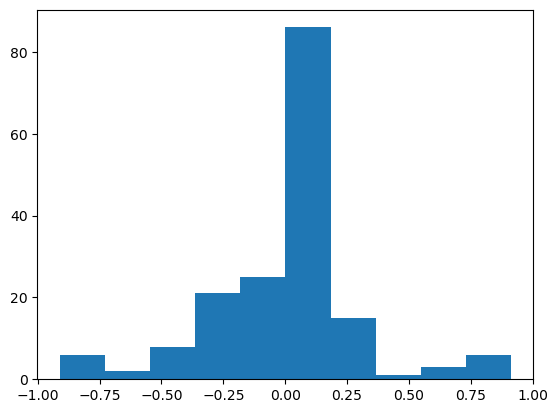

In [291]:
plt.hist(residuos)

In [293]:
from sklearn.metrics import accuracy_score
# Calcule a acurácia do modelo - o y precisa de ser binário
acuracia = accuracy_score(y, (y_pred>0.5))

# Imprima o resultado
print(acuracia)

0.8901734104046243


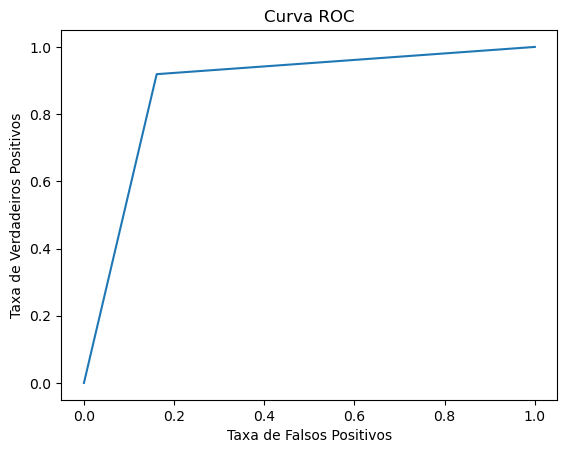

In [295]:
from sklearn.metrics import roc_curve

# Suponha que você tenha um conjunto de previsões 'y_pred' e um conjunto de valores observados 'y_true'

# Calcule as curvas ROC do modelo
fpr, tpr, thresholds = roc_curve(y, (y_pred>0.5))

# Plot o gráfico ROC
plt.plot(fpr, tpr)
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.show()

In [297]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [299]:
# Criamos o modelo de regressão logística
model = LogisticRegression()

# Treinamos o modelo com os dados de treinamento
model.fit(X_train, y_train)

LogisticRegression()

In [301]:
y_pred = model.predict_proba(X_train)[:, 1] #do lado esquerdo, a probabilidade de não acontecer, do lado direito o contrário

In [303]:
residuos = y_train - y_pred

In [305]:
residuos

40     0.039495
153    0.026852
22    -0.262998
106    0.028959
156    0.078710
         ...   
103    0.511373
67     0.084637
117   -0.059395
47     0.794722
172    0.136997
Name: probabilidade, Length: 121, dtype: float64

(array([ 3.,  2.,  3., 17., 17., 61., 11.,  2.,  1.,  4.]),
 array([-0.90464159, -0.72702857, -0.54941555, -0.37180252, -0.1941895 ,
        -0.01657648,  0.16103654,  0.33864957,  0.51626259,  0.69387561,
         0.87148863]),
 <BarContainer object of 10 artists>)

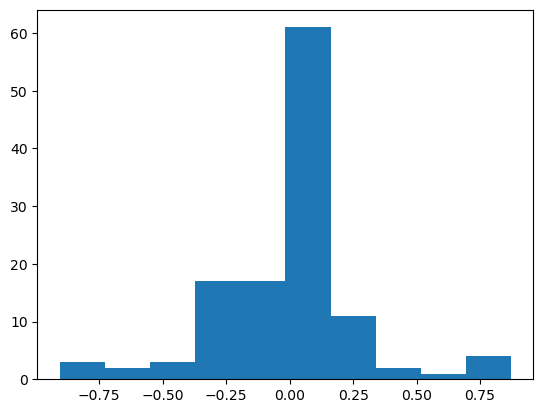

In [307]:
plt.hist(residuos)

In [309]:
from sklearn.metrics import accuracy_score
# Calcule a acurácia do modelo - o y precisa de ser binário
acuracia = accuracy_score(y_train, (y_pred>0.5))

# Imprima o resultado
print(acuracia)

0.8925619834710744


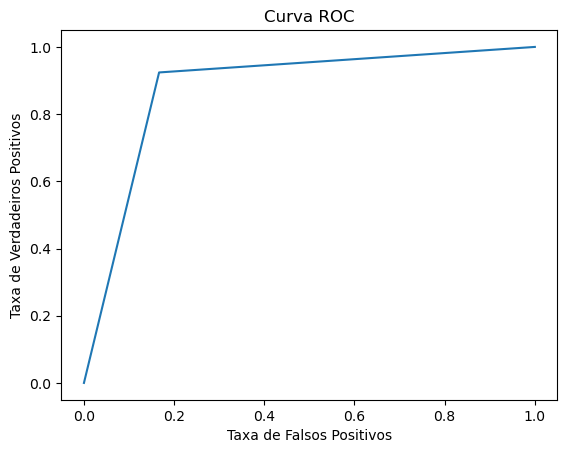

In [317]:
from sklearn.metrics import roc_curve

# Suponha que você tenha um conjunto de previsões 'y_pred' e um conjunto de valores observados 'y_true'

# Calcule as curvas ROC do modelo
fpr, tpr, thresholds = roc_curve(y_train, (y_pred>0.5))

# Plot o gráfico ROC
plt.plot(fpr, tpr)
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.show()




### Arvore de decisao e floresta aleatoria

In [322]:
import warnings
warnings.filterwarnings("ignore")

In [341]:
import pandas as pd
data2 = pd.read_csv("atlas2010_recorte.csv", delimiter=",")


In [345]:
X = data2[['espvida', 'fectot', 'mort1', 'razdep', 'e_anosestudo']]
y = data2[['uf']]

In [347]:
np.unique(y)

array(['Acre', 'Amapa', 'Amazonas', 'Maranhao', 'Para', 'Piaui',
       'Rondonia', 'Roraima', 'Tocantins'], dtype=object)

In [349]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

#### Aplicando um modelo simples de árvore de decisão

In [354]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

In [356]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [358]:
# Plotar a árvore
plt.figure(figsize=(200, 200))
plot_tree(clf, feature_names=['espvida', 'fectot', 'mort1', 'razdep', 'e_anosestudo'], class_names=['Acre', 'Amapa', 'Amazonas', 'Maranhao', 'Para', 'Piaui',
       'Rondonia', 'Roraima', 'Tocantins'])
plt.show()

In [360]:
tree = clf.tree_

In [362]:
print(f'Número de nós: {tree.node_count}')

Número de nós: 381


In [364]:
print(f'Profundidade máxima: {tree.max_depth}')

Profundidade máxima: 19


### Calculando a acurácia

In [367]:
from sklearn.metrics import accuracy_score

accuracy1 = accuracy_score(y_test, y_pred)

print(accuracy1)

0.6142322097378277


### Limitando o número de nós folha da árvore

In [370]:

from sklearn.tree import DecisionTreeClassifier

# Criar o classificador
clf_limit_nos = DecisionTreeClassifier(max_leaf_nodes=5)

# Treinar o classificador
clf_limit_nos.fit(X_train, y_train)

# Fazer previsões
y_pred2 = clf_limit_nos.predict(X_test)

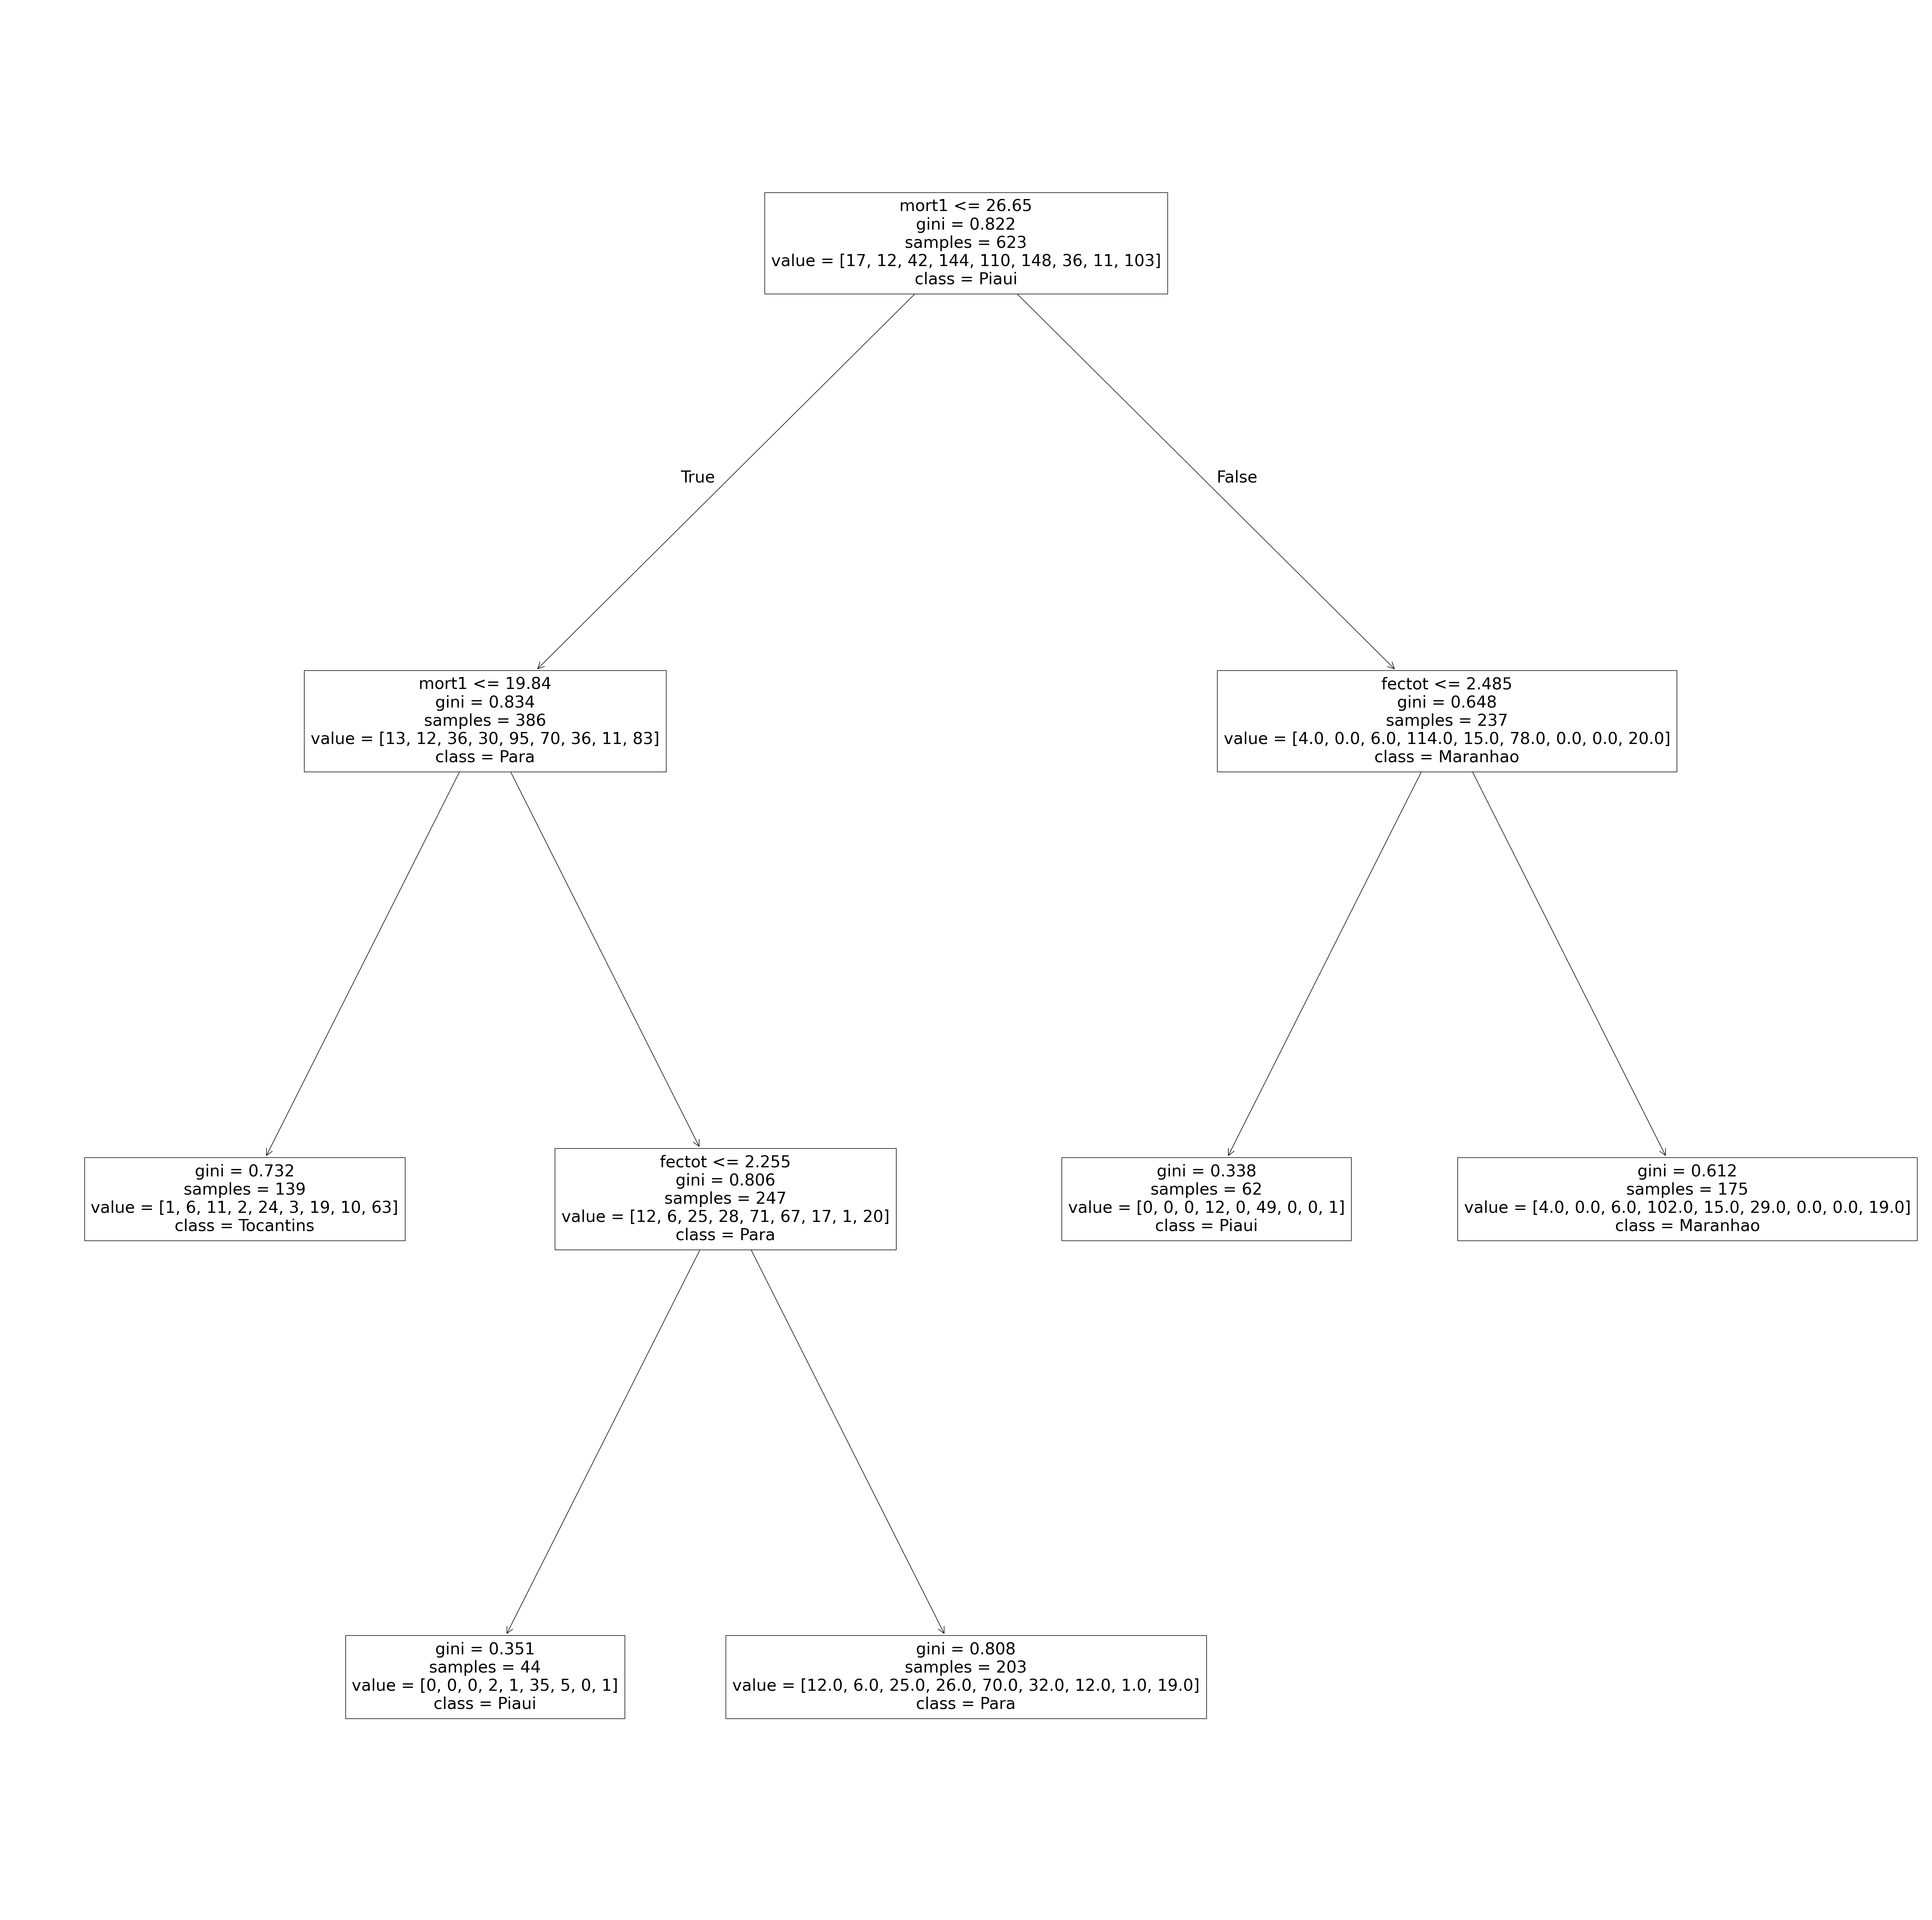

In [372]:
plt.figure(figsize=(60, 60))
plot_tree(clf_limit_nos, feature_names=['espvida', 'fectot', 'mort1', 'razdep', 'e_anosestudo'], class_names=['Acre', 'Amapa', 'Amazonas', 'Maranhao', 'Para', 'Piaui',
       'Rondonia', 'Roraima', 'Tocantins'])
plt.show()

### Calculando a acuária com nós limitados

In [375]:
accuracy2 = accuracy_score(y_test, y_pred2)
print(accuracy2)

0.5617977528089888


### Aplicando ID3 algoritmo de árvores de decisão

In [378]:
clf2 = DecisionTreeClassifier(criterion='entropy')
clf2.fit(X_train, y_train)

# Realiza a predição nos dados de teste
y_pred3 = clf2.predict(X_test)

# Avalia a performance do modelo
accuracy3 = accuracy_score(y_test, y_pred3)
print(accuracy3)

0.6554307116104869


## Trabalhando com florestas aleatórias

### Floresta Aleatória Classificadora

In [382]:
from sklearn.ensemble import RandomForestClassifier

clf3 = RandomForestClassifier(n_estimators=1000, random_state=0)

clf3.fit(X_train, y_train)

y_pred4 = clf3.predict(X_test)

# Avalia a performance do modelo
accuracy4 = accuracy_score(y_test, y_pred4)
print(accuracy4)

0.7191011235955056


### Floresta Aleatória Regressora

In [387]:
#Separando os dados
X2 = data2[['fectot', 'mort1', 'razdep', 'e_anosestudo']]
y2 = data2[['espvida']]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.3)

In [389]:
from sklearn.ensemble import RandomForestRegressor

clf4 = RandomForestRegressor(n_estimators=10000, random_state=0)

clf4.fit(X_train2, y_train2)

y_pred5 = clf4.predict(X_test2)

from sklearn.metrics import r2_score

r2 = r2_score(y_test2, y_pred5)
print("R²:", r2)

R²: 0.9696461719307238


## Modificando hiperparâmetros de florestas aleatórias

### Profundidade máxima das árvores (max_depth)

In [393]:
clf5 = RandomForestRegressor(n_estimators=1000, random_state=0, max_depth=5)

clf5.fit(X_train2, y_train2)

y_pred6 = clf5.predict(X_test2)

r2_2 = r2_score(y_test2, y_pred6)
print("R²:", r2_2)

R²: 0.9666908028502712


In [395]:
clf6 = RandomForestRegressor(n_estimators=1000, random_state=0, max_depth=10)

clf6.fit(X_train2, y_train2)

y_pred7 = clf6.predict(X_test2)

r2_21 = r2_score(y_test2, y_pred7)
print("R²:", r2_21)

R²: 0.9695655351673074


### Número mínimo de amostras para dividir um nó

In [398]:
clf7 = RandomForestRegressor(n_estimators=1000, random_state=0, min_samples_split=20)

clf7.fit(X_train2, y_train2)

y_pred8 = clf7.predict(X_test2)

r2_22 = r2_score(y_test2, y_pred8)
print("R²:", r2_22)

R²: 0.9687131746342679


In [400]:
clf8 = RandomForestRegressor(n_estimators=1000, random_state=0, min_samples_split=40)

clf8.fit(X_train2, y_train2)

y_pred9 = clf8.predict(X_test2)

r2_23 = r2_score(y_test2, y_pred9)
print("R²:", r2_23)

R²: 0.9613909588383915


### Número mínimo de amostras por folha

In [403]:
clf10 = RandomForestRegressor(n_estimators=1000, random_state=0, min_samples_leaf=10)

clf10.fit(X_train2, y_train2)

y_pred10 = clf10.predict(X_test2)

r2_24 = r2_score(y_test2, y_pred10)
print("R²:", r2_24)

R²: 0.9671527217642342


In [405]:
clf11 = RandomForestRegressor(n_estimators=1000, random_state=0, min_samples_leaf=20)

clf11.fit(X_train2, y_train2)

y_pred11 = clf11.predict(X_test2)

r2_25 = r2_score(y_test2, y_pred11)
print("R²:", r2_25)

R²: 0.9596606401821525


### Limitando número de nós folha

In [408]:
clf12 = RandomForestRegressor(n_estimators=1000, random_state=0, max_leaf_nodes=10)

clf12.fit(X_train2, y_train2)

y_pred12 = clf12.predict(X_test2)

r2_26 = r2_score(y_test2, y_pred12)
print("R²:", r2_26)

R²: 0.9550679363838818


In [410]:
clf13 = RandomForestRegressor(n_estimators=1000, random_state=0, max_leaf_nodes=20)

clf13.fit(X_train2, y_train2)

y_pred13 = clf13.predict(X_test2)

r2_27 = r2_score(y_test2, y_pred13)
print("R²:", r2_27)

R²: 0.9643732631618442


### Número de árvores de decisão na floresta aleatória

In [413]:
clf14 = RandomForestRegressor(n_estimators=10, random_state=0, max_leaf_nodes=10)

clf14.fit(X_train2, y_train2)

y_pred14 = clf14.predict(X_test2)

r2_28 = r2_score(y_test2, y_pred14)
print("R²:", r2_28)

R²: 0.9521809126523261


In [415]:
clf15 = RandomForestRegressor(n_estimators=20, random_state=0, max_leaf_nodes=10)

clf15.fit(X_train2, y_train2)

y_pred15 = clf15.predict(X_test2)

r2_29 = r2_score(y_test2, y_pred15)
print("R²:", r2_29)

R²: 0.9551978653189684
